In [11]:
from IPython.display import HTML
HTML("<style>.container{width:100%!important;margin:auto}div.cell,div.input_area{padding:2px;margin:0}div.output_wrapper{padding:0;margin:0}</style>")

# Machine Learning
## Topic: Unsupervised Learning — K-Means, K-Medoids, and Hierarchical Clustering

**Prerequisites you already have:** Python, Linear Algebra, Linear/Logistic Regression (Day 1-2), Decision Trees/Random Forest/K-NN (Day 3)

---
## A Big Shift Today: No More Labels!

Every algorithm so far (Linear Regression, Logistic Regression, Decision Trees, Random Forest, K-NN) was **supervised learning**: we always had a labeled "correct answer" column (`exam_score`, `passed`) that the model learned to predict.

Today we study **unsupervised learning**: the data has **NO labels at all**. There is no "correct answer" to predict. Instead, we ask the algorithm to find **hidden structure** in the data on its own — most commonly, to group similar data points together. This is called **Clustering**.

### Why would we ever want this?

| Scenario | What clustering finds |
|---|---|
| A store's customer purchase history | Groups of customers with similar shopping habits (customer segmentation) |
| Gene expression data | Groups of genes that behave similarly |
| News articles | Groups of articles about the same topic, with no one telling the computer the topics in advance |
| Photos of handwritten digits | Groups of similar-looking digits, without ever being told which digit is which |
| Students' study patterns | Groups of students with similar habits (e.g., "crammers" vs. "steady learners"), useful even without knowing final grades |

In every case above, we DON'T tell the algorithm the "true" groups in advance — it discovers them purely from how similar/different the data points are to each other.

### Today's three algorithms
1. **K-Means** — the most popular clustering algorithm; groups points around "center" points
2. **K-Medoids** — a more robust cousin of K-Means, resistant to outliers
3. **Hierarchical Clustering** — builds a whole tree of nested clusters, from individual points all the way up to one big cluster

### Learning Objectives
By the end of this notebook, you will be able to:
1. Explain the difference between supervised and unsupervised learning
2. Understand the K-Means algorithm step-by-step, including its objective function (WCSS/inertia)
3. Understand why K-Means struggles with outliers, and how the Elbow Method and Silhouette Score help pick K
4. Understand K-Medoids and why using an actual data point (a "medoid") instead of a mean makes it more robust
5. Understand Agglomerative Hierarchical Clustering, linkage criteria, and how to read a **dendrogram**
6. Implement all three algorithms from scratch (where feasible) and using scikit-learn/scipy
7. Compare the three algorithms and know when to choose each one


## Our Dataset for Today

We'll generate a synthetic 2D dataset with data naturally forming a few "blobs" (groups). In real life we would NOT know the true groups in advance — but since we're learning, we'll secretly keep the true group labels aside, just so we can check how well our clustering algorithms recover the real structure at the end.


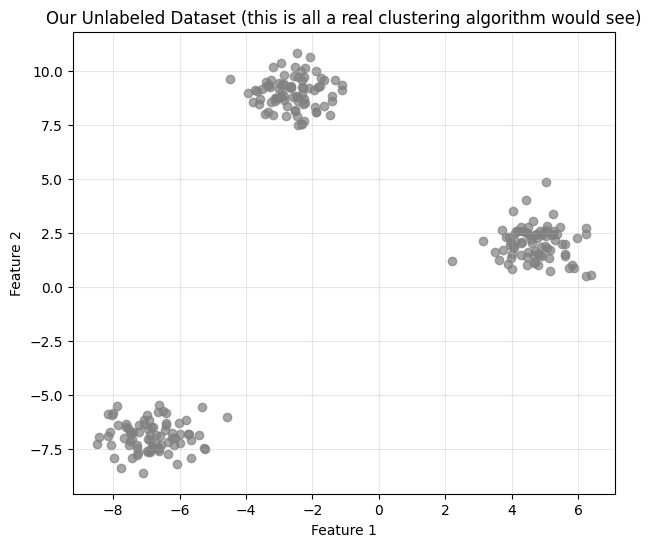

Notice: NO colors, NO labels -- just raw points. Our job is to find the groups ourselves.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate 3 well-separated "blobs" of points -- imagine these as 3 types of customers
X, true_labels = make_blobs(n_samples=240, centers=3, cluster_std=0.75, random_state=42)

df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])

plt.figure(figsize=(7, 6))
plt.scatter(df['feature_1'], df['feature_2'], color='gray', alpha=0.7)
plt.title("Our Unlabeled Dataset (this is all a real clustering algorithm would see)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

print("Notice: NO colors, NO labels -- just raw points. Our job is to find the groups ourselves.")


---
# PART 1: K-Means Clustering

## The Big Idea

K-Means tries to split the data into **K groups (clusters)**, where each cluster has a **center point**, called a **centroid**. Every data point is assigned to whichever centroid is closest to it. The algorithm repeatedly adjusts the centroids until the clusters stop changing.

### Vocabulary
- **K**: the number of clusters we want (we choose this number ourselves, before running the algorithm!)
- **Centroid**: the "center" of a cluster — literally the average (mean) position of all points currently in that cluster
- **Inertia / WCSS (Within-Cluster Sum of Squares)**: a single number measuring how tightly packed the clusters are (lower = better/tighter)

## The Objective Function (what K-Means is trying to minimize)

$$
WCSS = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2
$$

Breaking this down piece by piece:
- $C_k$ is the set of points currently assigned to cluster $k$
- $\mu_k$ is the centroid (mean position) of cluster $k$
- $\|x_i - \mu_k\|^2$ is the **squared Euclidean distance** from point $x_i$ to its cluster's centroid (same distance formula from K-NN on Day 3!)
- We sum this squared distance over every point in every cluster

**In plain English:** WCSS measures the total "spread" of points around their assigned centroids. A perfect clustering (where every point is exactly on top of its centroid) would have WCSS = 0. K-Means tries to find cluster assignments and centroid positions that make this total spread as SMALL as possible.

## The K-Means Algorithm — Step by Step

1. **Choose K** (the number of clusters), and randomly place K initial centroids (often just K random data points to start)
2. **Assignment step:** assign every data point to its NEAREST centroid (using Euclidean distance)
3. **Update step:** recompute each centroid as the **mean** (average position) of all points currently assigned to it
4. **Repeat** steps 2 and 3 until the centroids stop moving (or move by a tiny, negligible amount) — this is called **convergence**

This iterative "assign, then update, then repeat" process is sometimes called **Lloyd's Algorithm**.

### Why does this always converge?

Every assignment step can only decrease (or keep the same) the WCSS, because we're moving each point to its closest centroid. Every update step also only decreases (or keeps the same) the WCSS, because the mean is mathematically the point that minimizes total squared distance to a set of points. Since WCSS keeps decreasing (or staying flat) and can't go below 0, the algorithm is guaranteed to eventually stop changing.

### A subtlety: K-Means can get "stuck" in a bad local solution

Because the starting centroids are random, K-Means might converge to a mediocre clustering depending on where it started. In practice, we run K-Means multiple times with different random starting points and keep the best result (lowest WCSS) — scikit-learn does this automatically (`n_init` parameter). A smarter initialization method called **K-Means++** (which spreads out initial centroids intelligently rather than picking them totally randomly) is the modern default and greatly reduces this problem.


# K-Means Clustering: A Hands-On Example

Imagine you are designing a multiplayer video game. You have **4 players** waiting in a lobby, and you want to split them into **$K = 2$** matchmaking pools (a "Beginner" tier and a "Pro" tier) based on their skill levels.

### Our Players (Data Points):
*   **Player A:** Skill Level $2$
*   **Player B:** Skill Level $4$
*   **Player C:** Skill Level $10$
*   **Player D:** Skill Level $12$

Let's see exactly how the K-Means algorithm groups them mathematically.

---

## Step 1: Initialize the Centroids (Team Captains)
First, the algorithm randomly picks two starting levels to act as the "centers" of our two groups (centroids, represented by $\mu$).

*   **Centroid 1 ($\mu_1$):** $2$
*   **Centroid 2 ($\mu_2$):** $10$

---

## Step 2: Calculate Distances & Assign Players
We calculate the distance from each player's level ($x$) to both centroids using the simple 1D distance formula: 

$$\text{Distance} = |x - \mu|$$

### Player A (Level 2)
*   Distance to $\mu_1$: $|2 - 2| = 0$  *(Winner!)*
*   Distance to $\mu_2$: $|2 - 10| = 8$
*   **Assignment:** Cluster 1

### Player B (Level 4)
*   Distance to $\mu_1$: $|4 - 2| = 2$  *(Winner!)*
*   Distance to $\mu_2$: $|4 - 10| = 6$
*   **Assignment:** Cluster 1

### Player C (Level 10)
*   Distance to $\mu_1$: $|10 - 2| = 8$
*   Distance to $\mu_2$: $|10 - 10| = 0$  *(Winner!)*
*   **Assignment:** Cluster 2

### Player D (Level 12)
*   Distance to $\mu_1$: $|12 - 2| = 10$
*   Distance to $\mu_2$: $|12 - 10| = 2$  *(Winner!)*
*   **Assignment:** Cluster 2

### Grouping Summary (Round 1):
*   **Cluster 1 ($C_1$):** $\{2, 4\}$
*   **Cluster 2 ($C_2$):** $\{10, 12\}$

---

## Step 3: Update the Centroids
Now, we find the *real* center of each group by calculating the **mean (average)** of the points assigned to it.

$$\mu_{new} = \frac{\sum x_i}{N}$$

*   **New Centroid 1 ($\mu_1$):**
    $$\mu_1 = \frac{2 + 4}{2} = 3$$
*   **New Centroid 2 ($\mu_2$):**
    $$\mu_2 = \frac{10 + 12}{2} = 11$$

Our centroids have moved from $(2, 10)$ to **$(3, 11)$**.

---

## Step 4: Re-evaluate and Check for Convergence
Since the centroids moved, we have to recalculate the distances to see if any players want to switch clusters.

| Player Level ($x$) | Distance to $\mu_1$ ($3$) | Distance to $\mu_2$ ($11$) | Closest Centroid |
| :---: | :---: | :---: | :---: |
| **2** | $\|2 - 3\| = \mathbf{1}$ | $\|2 - 11\| = 9$ | **Cluster 1** |
| **4** | $\|4 - 3\| = \mathbf{1}$ | $\|4 - 11\| = 7$ | **Cluster 1** |
| **10** | $\|10 - 3\| = 7$ | $\|10 - 11\| = \mathbf{1}$ | **Cluster 2** |
| **12** | $\|12 - 3\| = 9$ | $\|12 - 11\| = \mathbf{1}$ | **Cluster 2** |

### Notice anything? 
The groups did not change! 
*   Cluster 1 is still $\{2, 4\}$
*   Cluster 2 is still $\{10, 12\}$

Because the cluster assignments remained exactly the same, the centroids will not move anymore. The algorithm has **converged** and stops. We successfully grouped our players!

## Let's implement K-Means completely from scratch (NumPy only)

We'll visualize each iteration so you can literally watch the centroids move and the clusters form.


In [13]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def kmeans_from_scratch(X, k, max_iters=10, random_state=42):
    rng = np.random.default_rng(random_state)

    # Step 1: Initialize centroids by randomly picking K actual data points
    initial_idx = rng.choice(len(X), size=k, replace=False)
    centroids = X[initial_idx].copy()

    history = []  # store (centroids, assignments) at each step, for visualization

    for iteration in range(max_iters):
        # Step 2: Assignment step -- assign each point to its nearest centroid
        distances = np.zeros((len(X), k))
        for cluster_idx in range(k):
            for point_idx in range(len(X)):
                distances[point_idx, cluster_idx] = euclidean_distance(X[point_idx], centroids[cluster_idx])
        assignments = np.argmin(distances, axis=1)  # index of the closest centroid for each point

        history.append((centroids.copy(), assignments.copy()))

        # Step 3: Update step -- move each centroid to the mean of its assigned points
        new_centroids = np.zeros_like(centroids)
        for cluster_idx in range(k):
            points_in_cluster = X[assignments == cluster_idx]
            if len(points_in_cluster) > 0:
                new_centroids[cluster_idx] = points_in_cluster.mean(axis=0)
            else:
                new_centroids[cluster_idx] = centroids[cluster_idx]  # avoid empty-cluster crash

        # Check for convergence: did centroids stop moving (within a tiny tolerance)?
        if np.allclose(new_centroids, centroids, atol=1e-6):
            centroids = new_centroids
            break

        centroids = new_centroids

    return centroids, assignments, history

X_arr = df[['feature_1', 'feature_2']].values
final_centroids, final_assignments, history = kmeans_from_scratch(X_arr, k=3, max_iters=10)

print(f"Converged after {len(history)} iterations.")
print(f"Final centroid positions:\n{final_centroids.round(2)}")


Converged after 3 iterations.
Final centroid positions:
[[-2.6   9.  ]
 [-6.86 -6.9 ]
 [ 4.71  2.03]]


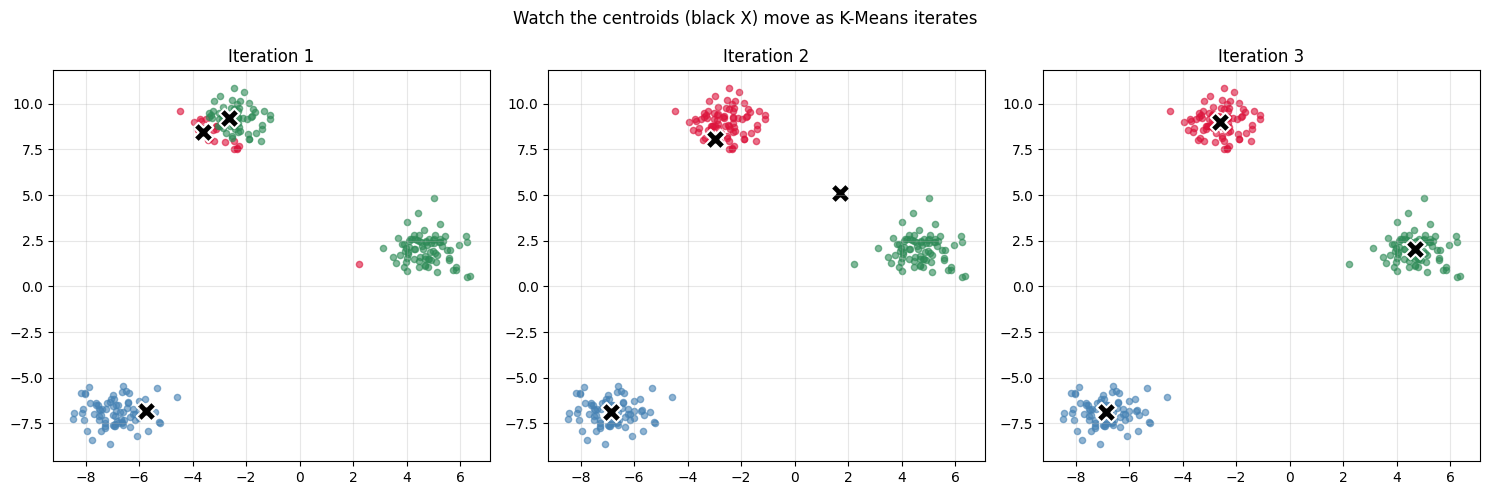

Each panel shows: colored points = current cluster assignment, black X = current centroid position.
Notice how the centroids move less and less each iteration, until they stabilize (converge).


In [14]:
# Visualize the first few iterations, so you can literally SEE the centroids moving and clusters forming
n_show = min(4, len(history))
fig, axes = plt.subplots(1, n_show, figsize=(5*n_show, 5))
if n_show == 1:
    axes = [axes]

colors = ['crimson', 'steelblue', 'seagreen', 'orange', 'purple']

for i in range(n_show):
    centroids_i, assignments_i = history[i]
    ax = axes[i]
    for cluster_idx in range(3):
        cluster_points = X_arr[assignments_i == cluster_idx]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[cluster_idx], alpha=0.6, s=20)
    ax.scatter(centroids_i[:, 0], centroids_i[:, 1], color='black', marker='X', s=200, edgecolor='white', linewidth=1.5)
    ax.set_title(f"Iteration {i+1}")
    ax.grid(True, alpha=0.3)

plt.suptitle("Watch the centroids (black X) move as K-Means iterates")
plt.tight_layout()
plt.show()

print("Each panel shows: colored points = current cluster assignment, black X = current centroid position.")
print("Notice how the centroids move less and less each iteration, until they stabilize (converge).")


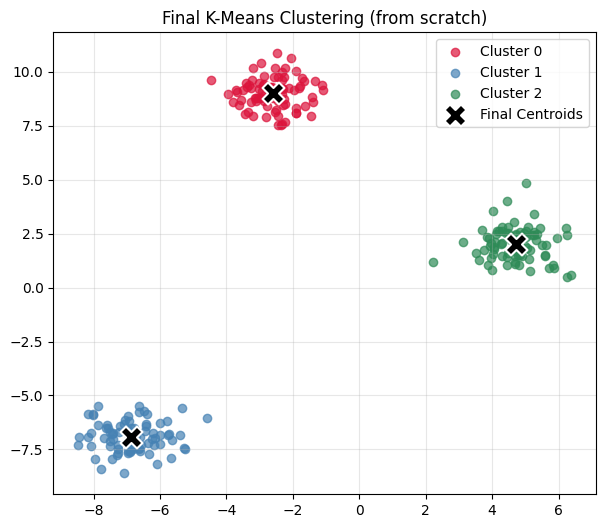

In [15]:
# Final clustering result from our from-scratch implementation
plt.figure(figsize=(7, 6))
for cluster_idx in range(3):
    cluster_points = X_arr[final_assignments == cluster_idx]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[cluster_idx], alpha=0.7, label=f'Cluster {cluster_idx}')
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], color='black', marker='X', s=250, edgecolor='white', linewidth=1.5, label='Final Centroids')
plt.title("Final K-Means Clustering (from scratch)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## The Big Question: How Do We Choose K?

Unlike supervised learning, there's no "correct answer" telling us the right number of clusters. We need other tools to help us decide.

### Method 1: The Elbow Method

We run K-Means for many different values of K (e.g., K=1 through K=10), and plot **WCSS (inertia) vs. K**.

- As K increases, WCSS will ALWAYS keep decreasing (more clusters = points can always get closer to *some* centroid). In fact, if K = number of data points, WCSS = 0 exactly (each point is its own cluster)!
- But we don't want that many clusters — we want the smallest K where adding more clusters stops giving us much benefit
- We look for the **"elbow"** in the curve — the point where the curve bends and flattens out, like a bent arm. Before the elbow, adding clusters helps a lot; after the elbow, it barely helps.

### Method 2: The Silhouette Score

A more mathematical way to evaluate clustering quality, for each point $i$:

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

Where:
- $a(i)$ = average distance from point $i$ to all OTHER points in its **own** cluster (how tightly it fits its own group)
- $b(i)$ = average distance from point $i$ to all points in the **nearest neighboring** cluster (how far it is from the closest OTHER group)

**Interpreting the Silhouette Score** (ranges from -1 to +1):
- **Close to +1**: the point is well-matched to its own cluster and far from other clusters (great clustering)
- **Close to 0**: the point is right on the border between two clusters (ambiguous)
- **Negative**: the point is probably in the WRONG cluster (it's actually closer to a different cluster than its own!)

We average $s(i)$ over all points to get one overall score for a given K. We then pick the K with the **highest average silhouette score**.


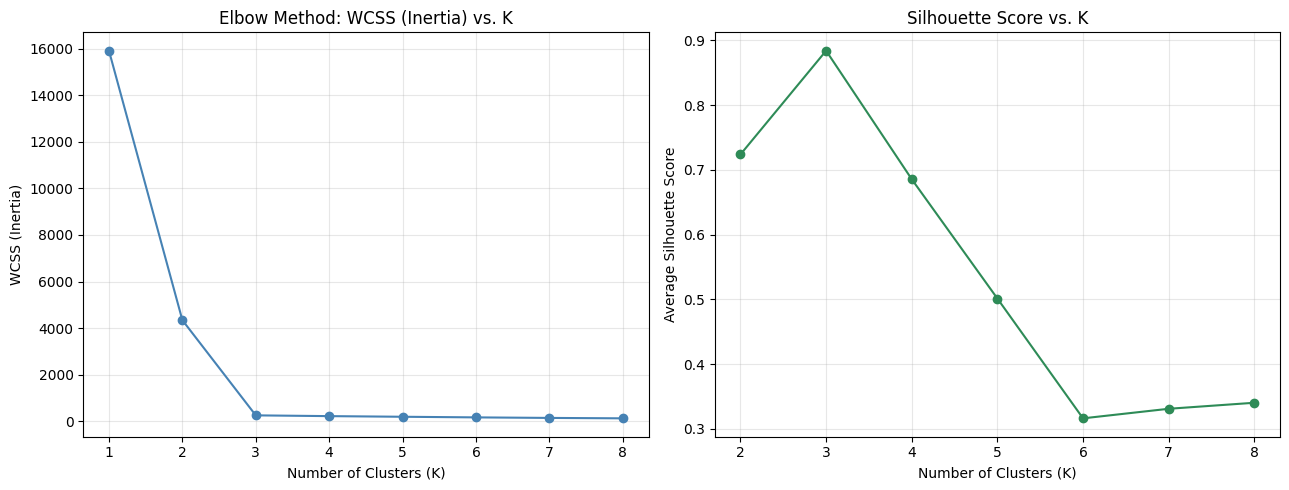

Best K according to Silhouette Score: 3
Look at the elbow plot too -- does the 'bend' in the curve agree with this K?


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss_values = []
silhouette_values = []
k_range = range(2, 9)  # silhouette score needs at least 2 clusters, so we start at K=2

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_arr)
    wcss_values.append(km.inertia_)  # scikit-learn calls WCSS "inertia_"
    silhouette_values.append(silhouette_score(X_arr, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow plot (note: we also compute K=1 separately just to show the starting point)
km1 = KMeans(n_clusters=1, n_init=10, random_state=42).fit(X_arr)
all_k = [1] + list(k_range)
all_wcss = [km1.inertia_] + wcss_values

axes[0].plot(all_k, all_wcss, marker='o', color='steelblue')
axes[0].set_title("Elbow Method: WCSS (Inertia) vs. K")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), silhouette_values, marker='o', color='seagreen')
axes[1].set_title("Silhouette Score vs. K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Average Silhouette Score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouette_values)]
print(f"Best K according to Silhouette Score: {best_k}")
print("Look at the elbow plot too -- does the 'bend' in the curve agree with this K?")


### Reading the plots above

In the **Elbow plot**, look for where the curve stops dropping steeply and starts to flatten — that "bend" (elbow) usually appears around K=3 for our dataset, which matches the fact that we generated exactly 3 blobs.

In the **Silhouette plot**, the highest point tells us the K that produces the best-separated, most tightly-packed clusters. Both methods should roughly agree — using them together gives us more confidence in choosing K.


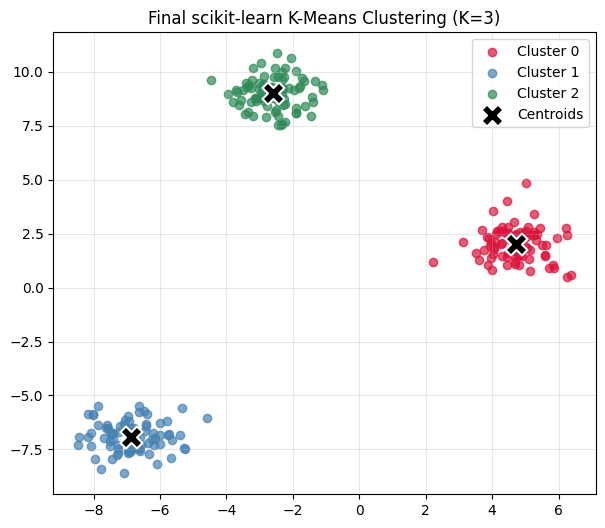

In [17]:
# Final K-Means model using our chosen K, with scikit-learn (much faster than our from-scratch version)
final_kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
cluster_labels = final_kmeans.fit_predict(X_arr)

plt.figure(figsize=(7, 6))
for cluster_idx in range(3):
    cluster_points = X_arr[cluster_labels == cluster_idx]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[cluster_idx], alpha=0.7, label=f'Cluster {cluster_idx}')
plt.scatter(final_kmeans.cluster_centers_[:, 0], final_kmeans.cluster_centers_[:, 1],
            color='black', marker='X', s=250, edgecolor='white', linewidth=1.5, label='Centroids')
plt.title("Final scikit-learn K-Means Clustering (K=3)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## A Weakness of K-Means: Sensitivity to Outliers

Because a centroid is the **mean (average)** of its cluster's points, a single extreme outlier can pull the centroid far away from where most of the cluster's points actually are — just like how one billionaire in a room can drastically raise the "average income" even though everyone else is middle-class.

Let's see this happen, and it will motivate our next algorithm: **K-Medoids**.


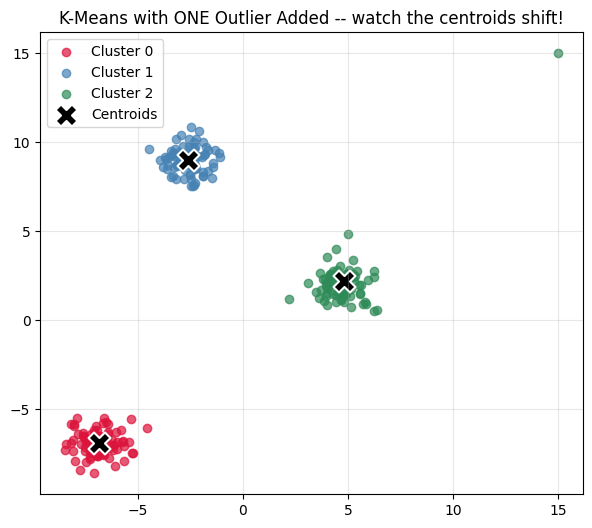

Notice how the single outlier point can distort a whole cluster's centroid position,
dragging it away from where most of that cluster's real points actually sit.


In [18]:
# Add a single extreme outlier point to our dataset
X_with_outlier = np.vstack([X_arr, [[15, 15]]])  # one far-away point

km_outlier = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_outlier = km_outlier.fit_predict(X_with_outlier)

plt.figure(figsize=(7, 6))
for cluster_idx in range(3):
    cluster_points = X_with_outlier[labels_outlier == cluster_idx]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[cluster_idx], alpha=0.7, label=f'Cluster {cluster_idx}')
plt.scatter(km_outlier.cluster_centers_[:, 0], km_outlier.cluster_centers_[:, 1],
            color='black', marker='X', s=250, edgecolor='white', linewidth=1.5, label='Centroids')
plt.title("K-Means with ONE Outlier Added -- watch the centroids shift!")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Notice how the single outlier point can distort a whole cluster's centroid position,")
print("dragging it away from where most of that cluster's real points actually sit.")


---
# PART 2: K-Medoids Clustering

## The Big Idea

K-Medoids works almost exactly like K-Means, with ONE crucial difference:

> Instead of using the **mean** (an artificial, calculated average point) as the cluster center, K-Medoids uses a **medoid** — an ACTUAL data point from the dataset that is most "centrally located" within its cluster.

### Why does this fix the outlier problem?

A medoid must be a real data point that already exists in the dataset. Since it's chosen to minimize total distance to other points in its cluster, a single far-away outlier can't "drag" the medoid toward itself the way it can drag a mean — the medoid will simply stay among the dense, central points, and the outlier will just be a poorly-fit point rather than corrupting the whole cluster's center.

## The Objective Function

$$
\text{Cost} = \sum_{k=1}^{K} \sum_{x_i \in C_k} d(x_i, m_k)
$$

Where:
- $m_k$ is the **medoid** of cluster $k$ (an actual data point, not a calculated average!)
- $d(x_i, m_k)$ is the distance between point $x_i$ and its cluster's medoid — this can be Euclidean distance, but K-Medoids can ALSO work with other distance measures (e.g., Manhattan distance), which is another advantage over K-Means

Notice this looks almost identical to K-Means' WCSS formula, except:
1. We use plain distance $d(x_i, m_k)$, not squared distance
2. The center $m_k$ must be an actual data point

## The PAM Algorithm (Partitioning Around Medoids) — Step by Step

PAM is the classic algorithm for K-Medoids:

1. **Initialize:** randomly select K data points to be the initial medoids
2. **Assignment step:** assign every point to its nearest medoid (same as K-Means)
3. **Update step (the key difference from K-Means):** for each medoid, try SWAPPING it with every non-medoid point in its cluster. If a swap reduces the total cost (sum of distances), keep the swap. Otherwise, keep the original medoid.
4. **Repeat** steps 2-3 until no swap improves the total cost (convergence)

### Trade-off: K-Medoids is more robust, but slower

Trying every possible swap (step 3) is much more computationally expensive than just calculating a mean (K-Means' update step). This is why K-Medoids is typically used on **smaller datasets**, or when we specifically know our data has outliers or needs a non-Euclidean distance measure.


# PART 2: K-Medoids Clustering (Multi-Iteration Walkthrough)

## The Big Idea
In **K-Means**, the center of a group (the centroid) is calculated as the average. This often results in a "fake" data point (like a skill level of $3.5$, even though no player actually has that level).

**K-Medoids** solves this by forcing the center of each group to be an **actual, real data point from our dataset**. This real-world representative is called a **Medoid** (think of them as the most "central" member of the group). 

K-Medoids is incredibly useful because it is **robust to outliers** (extreme values). If a Level 100 esports pro joins our casual lobby, a K-Means average gets dragged way up, but a K-Medoids center stays put with a normal player.

---

## The Video Game Example (with an Outlier!)

Let's say we have **5 players** in our lobby:
*   **Player A:** Level $2$
*   **Player B:** Level $4$
*   **Player C:** Level $5$
*   **Player D:** Level $10$
*   **Player E (Outlier):** Level $100$ *(A literal gaming god)*

We want to split them into **$K = 2$** matchmaking tiers. Let's trace the algorithm step-by-step through its iterations.

---

## ITERATION 1

### Step 1.1: Pick Initial Medoids (A poor random start)
We start with a random (and slightly awkward) initial guess for our two team leaders:
*   **Medoid 1 ($M_1$):** Player B (Level $4$)
*   **Medoid 2 ($M_2$):** Player C (Level $5$)

### Step 1.2: Assign Players to the Closest Medoid
We calculate the distance from every player to our two starting leaders.

| Player Level ($x$) | Distance to $M_1$ ($4$) | Distance to $M_2$ ($5$) | Assignment |
| :---: | :---: | :---: | :---: |
| **2** | $\|2 - 4\| = \mathbf{2}$ | $\|2 - 5\| = 3$ | **Cluster 1** |
| **4** | $\|4 - 4\| = \mathbf{0}$ | $\|4 - 5\| = 1$ | **Cluster 1** |
| **5** | $\|5 - 4\| = 1$ | $\|5 - 5\| = \mathbf{0}$ | **Cluster 2** |
| **10** | $\|10 - 4\| = 6$ | $\|10 - 5\| = \mathbf{5}$ | **Cluster 2** |
| **100** | $\|100 - 4\| = 96$ | $\|100 - 5\| = \mathbf{95}$ | **Cluster 2** |

#### Current Groups:
*   **Cluster 1:** $\{2, 4\}$ (with Medoid Level $4$)
*   **Cluster 2:** $\{5, 10, 100\}$ (with Medoid Level $5$)

---

## ITERATION 2

### Step 2.1: Update the Medoids (The Swap Test)
Now, we test the other players in both clusters to see if any of them would make a better, more "central" leader. We do this by calculating who has the **lowest total distance** to everyone else in their respective group.

#### Checking Cluster 1: $\{2, 4\}$
*   **If Player A (Level 2) is leader:** 
    $$\text{Total Dist} = |2-2| + |4-2| = \mathbf{2}$$
*   **If Player B (Level 4) stays leader:** 
    $$\text{Total Dist} = |2-4| + |4-4| = \mathbf{2}$$
*(Since there is a tie, we keep the current Medoid 1 at Level 4).*

#### Checking Cluster 2: $\{5, 10, 100\}$
*   **If Player C (Level 5) stays leader:**
    $$\text{Total Dist} = |5-5| + |10-5| + |100-5| = 0 + 5 + 95 = \mathbf{100}$$
*   **If Player D (Level 10) is leader:**
    $$\text{Total Dist} = |5-10| + |10-10| + |100-10| = 5 + 0 + 90 = \mathbf{95}$$
*   **If Player E (Level 100) is leader:**
    $$\text{Total Dist} = |5-100| + |10-100| + |100-100| = 95 + 90 + 0 = \mathbf{185}$$

**Winner for Cluster 2:** Player D (Level 10) has a lower total distance ($95$) than Player C ($100$). We swap Medoid 2 to **Player D (Level 10)**!

*   **New Medoid 1 ($M_1$):** Player B (Level $4$)
*   **New Medoid 2 ($M_2$):** Player D (Level $10$)

---

## ITERATION 3

### Step 3.1: Re-Assign Players to the Updated Medoids
With our updated team leaders, let's see if any players want to switch teams based on our new centroids ($4$ and $10$).

| Player Level ($x$) | Distance to $M_1$ ($4$) | Distance to $M_2$ ($10$) | Assignment |
| :---: | :---: | :---: | :---: |
| **2** | $\|2 - 4\| = \mathbf{2}$ | $\|2 - 10\| = 8$ | **Cluster 1** |
| **4** | $\|4 - 4\| = \mathbf{0}$ | $\|4 - 10\| = 6$ | **Cluster 1** |
| **5** | $\|5 - 4\| = \mathbf{1}$ | $\|5 - 10\| = 5$ | **Cluster 1** *(Switched!)* |
| **10** | $\|10 - 4\| = 6$ | $\|10 - 10\| = \mathbf{0}$ | **Cluster 2** |
| **100** | $\|100 - 4\| = 96$ | $\|100 - 10\| = \mathbf{90}$ | **Cluster 2** |

Because Medoid 2 moved to Level 10, **Player C (Level 5)** is now closer to Medoid 1 (Level 4, distance of 1) than to Medoid 2 (Level 10, distance of 5). Player C switches to Cluster 1!

#### Current Groups:
*   **Cluster 1:** $\{2, 4, 5\}$ (with Medoid Level $4$)
*   **Cluster 2:** $\{10, 100\}$ (with Medoid Level $10$)

---

## ITERATION 4 (Convergence Check)

### Step 4.1: Swap Test Again
Because the clusters changed, we must run the swap test one more time on our new groupings to make sure we still have the absolute best leaders.

#### Checking Cluster 1 $\{2, 4, 5\}$:
*   If Player A (Level 2) is leader: $|2-2| + |4-2| + |5-2| = \mathbf{5}$
*   If Player B (Level 4) is leader: $|2-4| + |4-4| + |5-4| = \mathbf{3}$ *(Winner)*
*   If Player C (Level 5) is leader: $|2-5| + |4-5| + |5-5| = \mathbf{4}$

**Medoid 1 stays at Level 4.**

#### Checking Cluster 2 $\{10, 100\}$:
*   If Player D (Level 10) is leader: $|10-10| + |100-10| = \mathbf{90}$ *(Winner)*
*   If Player E (Level 100) is leader: $|10-100| + |100-100| = \mathbf{90}$

**Medoid 2 stays at Level 10.**

### Step 4.2: Final Check
Since the medoids did not change, our assignments will not change. The algorithm has **officially converged and stops!**

In [19]:
# Let's implement a simplified version of the PAM algorithm from scratch

def compute_total_cost(X, medoid_indices, assignments):
    total = 0
    for cluster_idx, medoid_idx in enumerate(medoid_indices):
        cluster_points_idx = np.where(assignments == cluster_idx)[0]
        for point_idx in cluster_points_idx:
            total += euclidean_distance(X[point_idx], X[medoid_idx])
    return total

def assign_to_nearest_medoid(X, medoid_indices):
    k = len(medoid_indices)
    distances = np.zeros((len(X), k))
    for cluster_idx, medoid_idx in enumerate(medoid_indices):
        for point_idx in range(len(X)):
            distances[point_idx, cluster_idx] = euclidean_distance(X[point_idx], X[medoid_idx])
    return np.argmin(distances, axis=1)

def kmedoids_from_scratch(X, k, max_iters=15, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(X)

    # Step 1: randomly pick K initial medoid INDICES (actual data points)
    medoid_indices = list(rng.choice(n, size=k, replace=False))

    assignments = assign_to_nearest_medoid(X, medoid_indices)
    best_cost = compute_total_cost(X, medoid_indices, assignments)

    for iteration in range(max_iters):
        improved = False

        # Step 3: try swapping each medoid with each non-medoid point
        for cluster_idx, medoid_idx in enumerate(medoid_indices):
            non_medoid_candidates = [i for i in range(n) if i not in medoid_indices]

            for candidate_idx in non_medoid_candidates:
                # Try this swap
                new_medoid_indices = medoid_indices.copy()
                new_medoid_indices[cluster_idx] = candidate_idx

                new_assignments = assign_to_nearest_medoid(X, new_medoid_indices)
                new_cost = compute_total_cost(X, new_medoid_indices, new_assignments)

                if new_cost < best_cost:
                    # This swap improves things -- keep it!
                    medoid_indices = new_medoid_indices
                    assignments = new_assignments
                    best_cost = new_cost
                    improved = True

        if not improved:
            break  # no swap improved the cost -- converged

    return medoid_indices, assignments, best_cost

# NOTE: full PAM (trying every possible swap) is slow -- we'll run it on a smaller sample
# of our data (60 points) purely so it finishes quickly for our in-class demo.
sample_idx = np.random.default_rng(0).choice(len(X_arr), size=60, replace=False)
X_sample = X_arr[sample_idx]

medoid_idx_result, assignments_result, final_cost = kmedoids_from_scratch(X_sample, k=3, max_iters=10)
print(f"Final total cost: {final_cost:.2f}")
print(f"Medoid data points (actual coordinates from the dataset):")
print(X_sample[medoid_idx_result].round(2))


Final total cost: 51.41
Medoid data points (actual coordinates from the dataset):
[[-6.89 -7.1 ]
 [ 5.03  2.36]
 [-2.65  9.24]]


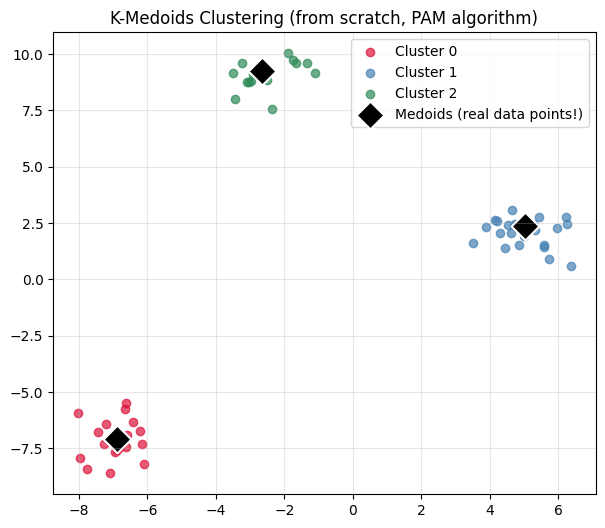

Notice the medoids (diamonds) are REAL data points sitting inside the clusters,
unlike K-Means centroids which are artificial calculated averages.


In [20]:
plt.figure(figsize=(7, 6))
for cluster_idx in range(3):
    cluster_points = X_sample[assignments_result == cluster_idx]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[cluster_idx], alpha=0.7, label=f'Cluster {cluster_idx}')

medoid_points = X_sample[medoid_idx_result]
plt.scatter(medoid_points[:, 0], medoid_points[:, 1], color='black', marker='D', s=200,
            edgecolor='white', linewidth=1.5, label='Medoids (real data points!)')
plt.title("K-Medoids Clustering (from scratch, PAM algorithm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Notice the medoids (diamonds) are REAL data points sitting inside the clusters,")
print("unlike K-Means centroids which are artificial calculated averages.")


## Demonstrating K-Medoids' Robustness to Outliers

Let's redo our earlier outlier experiment, but with K-Medoids this time, and compare directly to what happened with K-Means.


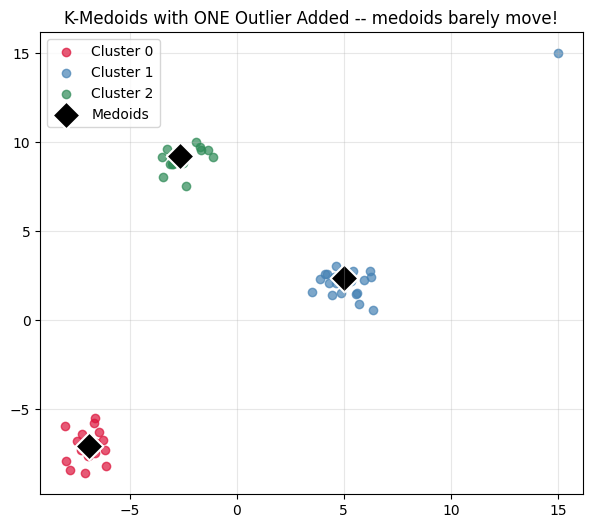

Compare this to the K-Means outlier experiment earlier: the medoids for the un-affected
clusters stay put among the real, dense data points -- only the outlier's own tiny
'cluster of one' is affected, instead of dragging a whole cluster's center off target.


In [21]:
# Add the same outlier to a smaller sample so our from-scratch PAM runs quickly
X_sample_outlier = np.vstack([X_sample, [[15, 15]]])

medoid_idx_outlier, assignments_outlier, cost_outlier = kmedoids_from_scratch(X_sample_outlier, k=3, max_iters=10)

plt.figure(figsize=(7, 6))
for cluster_idx in range(3):
    cluster_points = X_sample_outlier[assignments_outlier == cluster_idx]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[cluster_idx], alpha=0.7, label=f'Cluster {cluster_idx}')

medoid_points_outlier = X_sample_outlier[medoid_idx_outlier]
plt.scatter(medoid_points_outlier[:, 0], medoid_points_outlier[:, 1], color='black', marker='D', s=200,
            edgecolor='white', linewidth=1.5, label='Medoids')
plt.title("K-Medoids with ONE Outlier Added -- medoids barely move!")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Compare this to the K-Means outlier experiment earlier: the medoids for the un-affected")
print("clusters stay put among the real, dense data points -- only the outlier's own tiny")
print("'cluster of one' is affected, instead of dragging a whole cluster's center off target.")


## K-Means vs. K-Medoids — Side by Side

| Aspect | K-Means | K-Medoids |
|---|---|---|
| Cluster center | **Centroid** (mean of points — an artificial calculated point) | **Medoid** (an actual real data point) |
| Distance metric | Usually only Euclidean (squared) | Any distance metric (Euclidean, Manhattan, etc.) |
| Robustness to outliers | Low — a mean can be dragged by extreme values | High — center stays a real, representative point |
| Speed | Fast (mean is a cheap calculation) | Slower (must test swaps between points) |
| Best used when | Data is fairly clean, large datasets, spherical clusters | Data has outliers/noise, or needs non-Euclidean distance, smaller datasets |


# PART 3: Hierarchical Clustering

## The Big Idea

Both **K-Means** and **K-Medoids** require us to choose **K (number of clusters) before training**.

But often we do not know how many groups exist.

Hierarchical Clustering solves this differently:

> It builds a complete **tree of clusters**, starting from every point alone and gradually combining them until all points become one big cluster.

After building the tree, **we decide how many clusters we want by cutting the tree at the desired level**.

---

# A Simple Real-Life Example

Imagine six children standing in a playground.

| Child | Position |
|:-----:|:--------:|
| A | (1,1) |
| B | (2,1) |
| C | (2,2) |
| D | (8,8) |
| E | (9,8) |
| F | (8,9) |

The algorithm does not know anything about these children.

It only sees their positions.

It discovers:

- A, B, C are close together.
- D, E, F are close together.

---

# How Agglomerative Hierarchical Clustering Works

We will focus on the most common type:

## Agglomerative (Bottom-Up)

It means:

> Start with small groups and keep merging them.

### Step 1: Start

Every point is its own cluster.

```
A   B   C   D   E   F
```

6 clusters.

---

### Step 2: Find Closest Clusters

A and B are closest.

Merge them:

```
(AB)   C   D   E   F
```

---

### Step 3: Continue Merging

C is closest to (AB).

```
(ABC)   D   E   F
```

On the other side:

```
(ABC)   (DE)   F
```

Then:

```
(ABC)   (DEF)
```

Finally:

```
(ABCDEF)
```

All points become one cluster.

---

# The Complete Hierarchy

The algorithm records every merge:

```
                All Children
               /            \
          (ABC)              (DEF)
          /   \              /   \
       (AB)   C           (DE)    F
        / \                / \
       A   B              D   E
```

This tree is called a **Dendrogram**.

---

# Two Types of Hierarchical Clustering

## 1. Agglomerative (Bottom-Up) 

Most commonly used.

Steps:

1. Start with every point as its own cluster.
2. Calculate distances between clusters.
3. Merge the two closest clusters.
4. Repeat until one large cluster remains.
5. Record every merge to create the dendrogram.

---

## 2. Divisive (Top-Down)

Opposite approach:

1. Start with all points in one cluster.
2. Split clusters repeatedly.
3. Continue until small clusters are created.

It is less common because it is more expensive.

---

# How Do We Measure Distance Between Clusters?

When clusters contain many points, we need a rule to decide:

"How far apart are these two clusters?"

This rule is called **Linkage**.

---

## 1. Single Linkage (Closest Points)

Distance between the closest pair:

$$
d(A,B)=\min_{a\in A,b\in B}d(a,b)
$$

Example:

```
A •        • B
   \      /
    closest distance
```

Advantages:
- Finds connected groups.

Disadvantage:
- Can create long chain-like clusters.

---

## 2. Complete Linkage (Farthest Points)

Distance between the farthest pair:

$$
d(A,B)=\max_{a\in A,b\in B}d(a,b)
$$

Creates compact, tight clusters.

---

## 3. Average Linkage

Average distance between all points:

$$
d(A,B)=
\frac{1}{|A||B|}
\sum_{a\in A}\sum_{b\in B}d(a,b)
$$

A balance between single and complete linkage.

---

## 4. Ward Linkage 

Most commonly used.

Ward linkage merges clusters that create the smallest increase in:

$$
\text{Within Cluster Variance}
$$

It tries to keep clusters compact and similar to the idea behind K-Means.

---


```text
                    (ABCDEF)
                        |
                        |  Distance = 8
------------------------|----------------  ← Best place to cut
               _________|_________
              /                   \
           (ABC)               (DEF)
             |                    |
         Distance = 2        Distance = 2
          ___|___             ___|___
         /       \           /       \
      (AB)       C        (DE)       F
        |                    |
   Distance = 1        Distance = 1
      _|_                  _|_
     A   B                D   E
```


# Hierarchical vs K-Means

| Feature | K-Means | Hierarchical |
|:---|:---|:---|
| Need K before training | Yes | No |
| Creates tree | No | Yes |
| Works well for small data | Good | Excellent |
| Visualization | Low | High |
| Uses distance | Yes | Yes |

---
* Summary: Hierarchical clustering creates a **tree of clusters**.
**First → find closest friends → create small groups → merge similar groups → create bigger communities.**


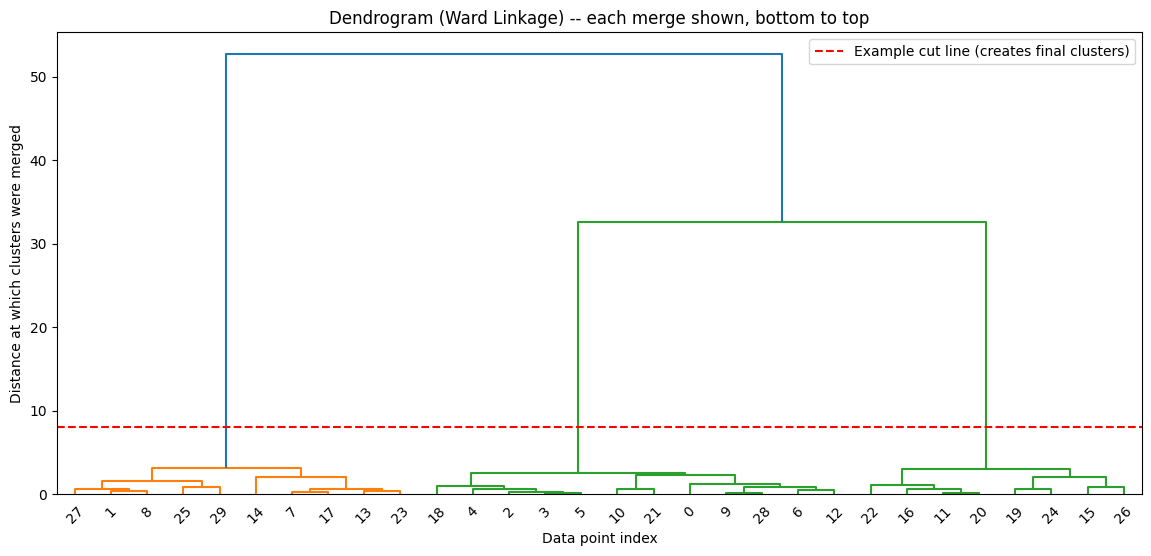

Read this bottom-up: individual points merge into small clusters first (low height),
then those small clusters merge into bigger ones (higher up), until everything
eventually merges into one root at the very top.

The red dashed line shows an example 'cut' -- every vertical line it crosses
becomes one final cluster.


In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

# For a readable dendrogram, let's use a smaller sample of our data (30 points)
sample_idx_small = np.random.default_rng(1).choice(len(X_arr), size=30, replace=False)
X_small = X_arr[sample_idx_small]

# scipy's 'linkage' function performs the full agglomerative merging process,
# and returns a record of every merge -- this record is what we plot as a dendrogram.
Z = linkage(X_small, method='ward')  # 'ward' linkage, as discussed above

plt.figure(figsize=(14, 6))
dendrogram(Z)
plt.title("Dendrogram (Ward Linkage) -- each merge shown, bottom to top")
plt.xlabel("Data point index")
plt.ylabel("Distance at which clusters were merged")
plt.axhline(y=8, color='red', linestyle='--', label='Example cut line (creates final clusters)')
plt.legend()
plt.show()

print("Read this bottom-up: individual points merge into small clusters first (low height),")
print("then those small clusters merge into bigger ones (higher up), until everything")
print("eventually merges into one root at the very top.")
print("\nThe red dashed line shows an example 'cut' -- every vertical line it crosses")
print("becomes one final cluster.")


Cutting the dendrogram at height=8 produces 3 clusters.


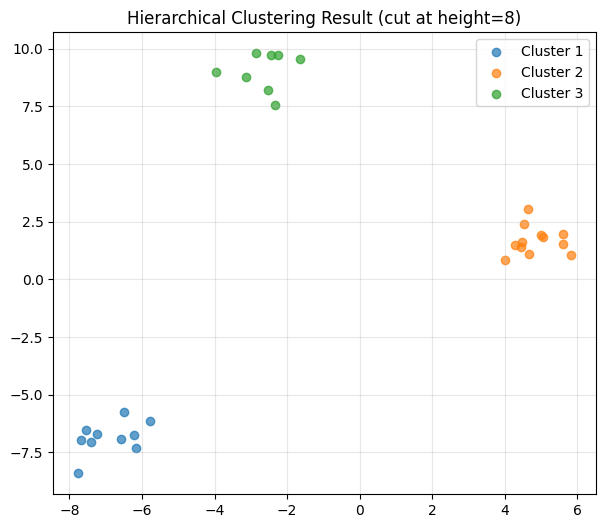

In [23]:
# Let's actually CUT the dendrogram at a specific height to get real cluster assignments
cut_height = 8
cluster_assignments = fcluster(Z, t=cut_height, criterion='distance')

n_clusters_found = len(np.unique(cluster_assignments))
print(f"Cutting the dendrogram at height={cut_height} produces {n_clusters_found} clusters.")

plt.figure(figsize=(7, 6))
for cluster_id in np.unique(cluster_assignments):
    cluster_points = X_small[cluster_assignments == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], alpha=0.7, label=f'Cluster {cluster_id}')
plt.title(f"Hierarchical Clustering Result (cut at height={cut_height})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


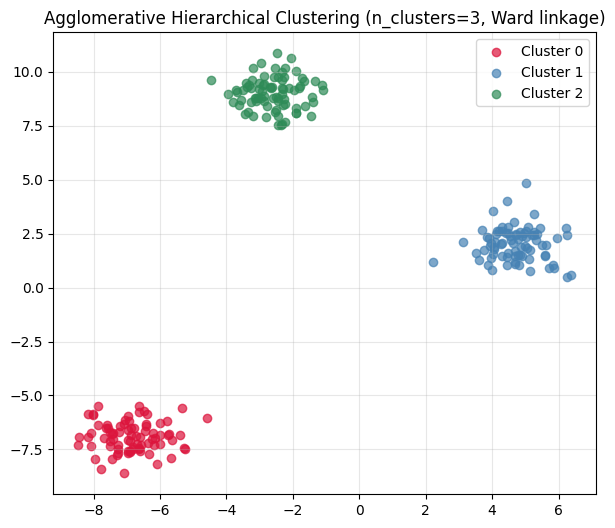

In [24]:
# In practice, we usually just tell scikit-learn how many clusters we WANT directly,
# and it figures out where to cut the tree for us.

agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_arr)  # back to our full dataset

plt.figure(figsize=(7, 6))
for cluster_idx in range(3):
    cluster_points = X_arr[agg_labels == cluster_idx]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[cluster_idx], alpha=0.7, label=f'Cluster {cluster_idx}')
plt.title("Agglomerative Hierarchical Clustering (n_clusters=3, Ward linkage)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Comparing Linkage Methods

Different linkage criteria can produce noticeably different clusters on the SAME data. Let's compare all four on our small sample.


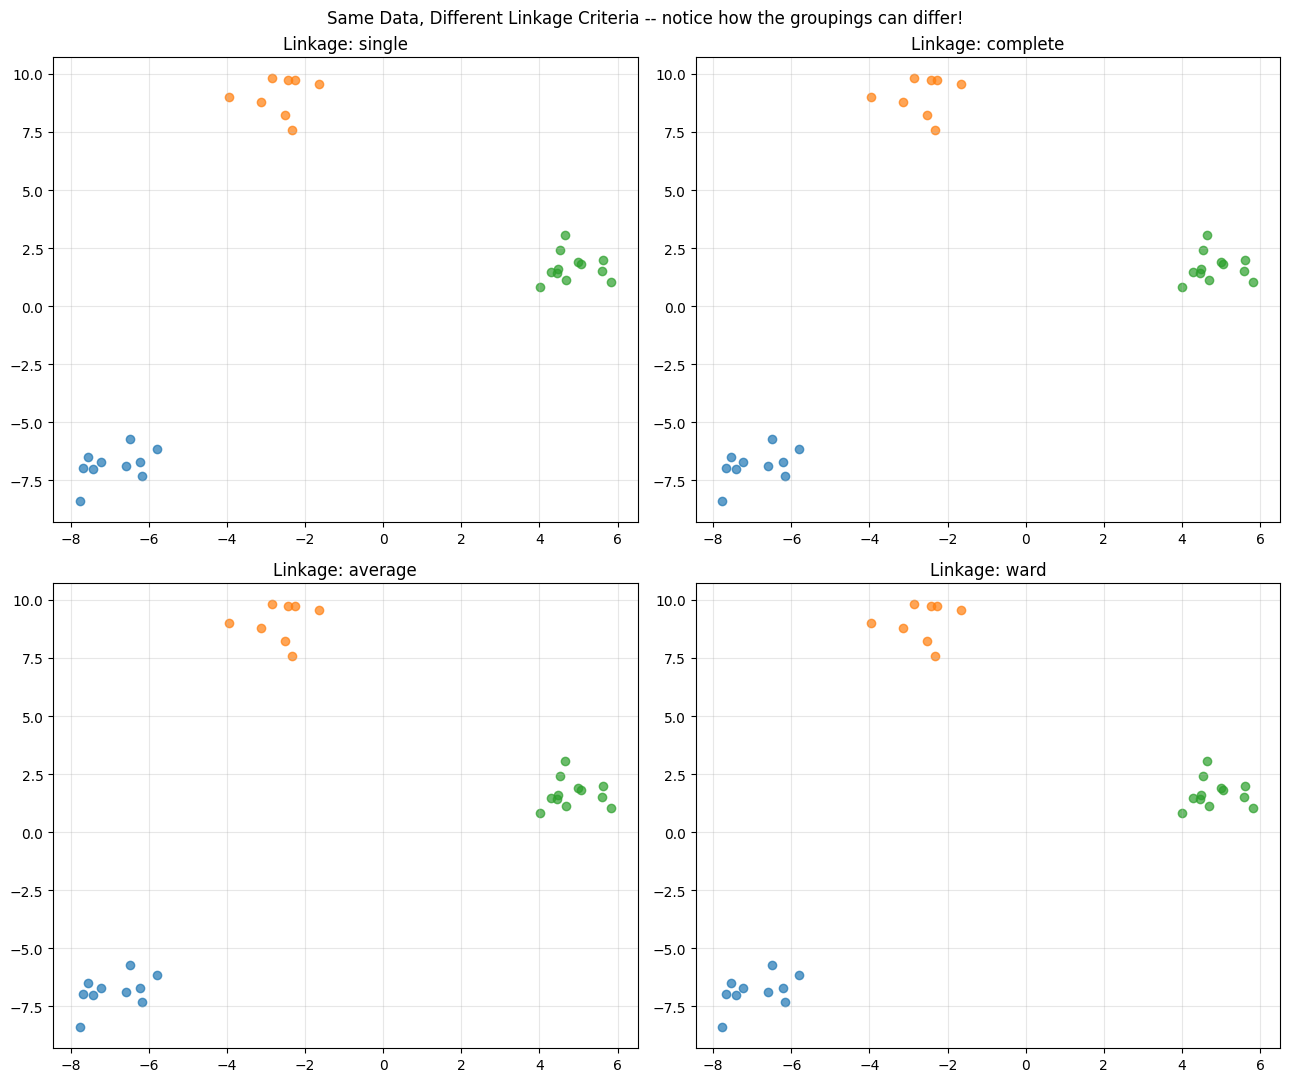

'single' linkage can sometimes produce one large chain-like cluster and tiny leftover ones,
since it only cares about the single closest pair of points between clusters.
'ward' and 'complete' tend to produce more balanced, evenly-sized clusters.


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
linkage_methods = ['single', 'complete', 'average', 'ward']

for ax, method in zip(axes.ravel(), linkage_methods):
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = agg.fit_predict(X_small)
    for cluster_idx in np.unique(labels):
        pts = X_small[labels == cluster_idx]
        ax.scatter(pts[:, 0], pts[:, 1], alpha=0.7)
    ax.set_title(f"Linkage: {method}")
    ax.grid(True, alpha=0.3)

plt.suptitle("Same Data, Different Linkage Criteria -- notice how the groupings can differ!")
plt.tight_layout()
plt.show()

print("'single' linkage can sometimes produce one large chain-like cluster and tiny leftover ones,")
print("since it only cares about the single closest pair of points between clusters.")
print("'ward' and 'complete' tend to produce more balanced, evenly-sized clusters.")


---
# Final Comparison: K-Means vs. K-Medoids vs. Hierarchical Clustering

Let's line up all three approaches on the SAME dataset and compare their silhouette scores.


In [26]:
from sklearn.metrics import silhouette_score

# 1. K-Means
km_final = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_arr)
km_sil = silhouette_score(X_arr, km_final.labels_)

# 2. K-Medoids (from-scratch, using our small sample for speed)
_, kmedoids_labels, _ = kmedoids_from_scratch(X_sample, k=3, max_iters=10)
kmedoids_sil = silhouette_score(X_sample, kmedoids_labels)

# 3. Hierarchical (Ward)
agg_final = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(X_arr)
agg_sil = silhouette_score(X_arr, agg_final.labels_)

results = pd.DataFrame({
    'Algorithm': ['K-Means', 'K-Medoids (sample)', 'Hierarchical (Ward)'],
    'Silhouette Score': [km_sil, kmedoids_sil, agg_sil]
}).sort_values('Silhouette Score', ascending=False)

print(results.to_string(index=False))
print("\n(Note: K-Medoids was run on a smaller sample for speed in this demo,")
print("so its silhouette score isn't perfectly comparable -- in production you'd run all")
print("three on the identical full dataset.)")


          Algorithm  Silhouette Score
 K-Medoids (sample)          0.891426
            K-Means          0.883960
Hierarchical (Ward)          0.883960

(Note: K-Medoids was run on a smaller sample for speed in this demo,
so its silhouette score isn't perfectly comparable -- in production you'd run all
three on the identical full dataset.)


## Summary Table: When Would You Use Each Algorithm?

| Algorithm | Cluster center | Must choose K upfront? | Robust to outliers? | Speed | Best for |
|---|---|---|---|---|---|
| **K-Means** | Centroid (mean) | Yes | No | Fast | Large, clean datasets with roughly round/spherical clusters |
| **K-Medoids** | Medoid (real point) | Yes | Yes | Slower | Smaller datasets with outliers, or non-Euclidean distances |
| **Hierarchical (Agglomerative)** | N/A (builds full tree) | No — decide after seeing the dendrogram | Depends on linkage | Slower on large data | When you want to explore different numbers of clusters, or want a visual tree of relationships |


# Summary of Today's Lecture

### Unsupervised Learning
- No labels — the algorithm finds hidden structure purely from the data itself
- Clustering groups similar points together

### K-Means
- Assigns points to the nearest **centroid** (mean position), then updates centroids, repeating until convergence
- Minimizes **WCSS** (within-cluster sum of squared distances)
- Choose K using the **Elbow Method** and/or **Silhouette Score**
- Weakness: sensitive to outliers, since a mean can be dragged by extreme values

### K-Medoids
- Same idea as K-Means, but uses a **medoid** (an actual data point) instead of a mean
- Uses the **PAM algorithm**: repeatedly try swapping medoids with non-medoid points if it reduces total cost
- More robust to outliers, works with any distance metric, but slower than K-Means

### Hierarchical Clustering (Agglomerative)
- Builds a full tree (**dendrogram**) by repeatedly merging the closest pair of clusters, starting from every point as its own cluster
- **Linkage criteria** (single, complete, average, ward) define how "distance between clusters" is measured
- You choose the number of clusters AFTERWARDS, by cutting the dendrogram at a chosen height — no need to guess K in advance

---
### Practice Exercises (try before next class)
1. Re-run the from-scratch K-Means with a different `random_state` for centroid initialization. Do you always get the same final clusters? What does this tell you about why scikit-learn tries multiple random initializations (`n_init`)?
2. Try the Elbow Method and Silhouette Score on a dataset you generate yourself with `centers=5` in `make_blobs`. Does the best K correctly come out to 5?
3. Add TWO outliers (not just one) to the K-Means and K-Medoids outlier experiments. Does K-Medoids still stay robust?
4. Change the `cut_height` in the dendrogram example to a much smaller and much larger number. How does the number of resulting clusters change?